# SlotODE — Slot Trajectory Visualization

Visualizes how slot representations evolve during the ODE integration in the SlotODE model.
We load the best checkpoint, run inference with `return_traj=True`, and plot:
1. Input images, reconstructions, and per-slot masks
2. Slot mask evolution across ODE time steps
3. PCA projection of slot trajectories in latent space

In [1]:
import pickle
from pathlib import Path

import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA

from model import SlotODEModel

print(f"JAX devices: {jax.devices()}")

JAX devices: [CudaDevice(id=0)]


## 1. Load checkpoint

In [2]:
CKPT_PATH = "runs_data/main_slot_ode_11_slots/checkpoints/best.eqx"
META_PATH = CKPT_PATH.replace(".eqx", "_meta.pkl")

with open(META_PATH, "rb") as f:
    meta = pickle.load(f)

ckpt_args = meta["args"]
print(f"Checkpoint trained for {meta['step']:,} steps, best val loss: {meta['best_val_loss']:.6f}")
print(f"Model config: {ckpt_args}")

Checkpoint trained for 500,000 steps, best val loss: 0.000475
Model config: {'model': 'slot_ode', 'solver': 'euler', 'data_dir': 'CLEVR_64', 'resolution': 64, 'batch_size': 64, 'lr': 0.0004, 'warmup_steps': 10000, 'decay_steps': 100000, 'decay_rate': 0.5, 'total_steps': 500000, 'num_slots': 11, 'slot_dim': 64, 'enc_hidden_dim': 64, 'num_iter': 3, 'dt': None, 'd_emb': 32, 'n_freq': 16, 'log_every': 100, 'val_every': 5000, 'img_every': 5000, 'ckpt_every': 10000, 'ckpt_dir': 'checkpoints', 'experiment': 'slot_ode_jax', 'run_name': None, 'seed': 42, 'grad_clip': 1.0, 'resume': None, 'gcs_ckpt': None}


In [3]:
resolution = (ckpt_args["resolution"], ckpt_args["resolution"])

key = jax.random.key(0)
model = SlotODEModel(
    resolution=resolution,
    num_slots=ckpt_args["num_slots"],
    slot_dim=ckpt_args["slot_dim"],
    enc_hidden_dim=ckpt_args["enc_hidden_dim"],
    num_iter=ckpt_args["num_iter"],
    solver=ckpt_args.get("solver", "euler"),
    dt0=ckpt_args.get("dt", None) or 1.0,
    d_emb=ckpt_args.get("d_emb", 64),
    n_freq=ckpt_args.get("n_freq", 128),
    key=key,
)

model = eqx.tree_deserialise_leaves(CKPT_PATH, model)
n_params = sum(p.size for p in jax.tree.leaves(eqx.filter(model, eqx.is_array)))
print(f"Loaded model: {n_params:,} parameters")

Loaded model: 1,971,524 parameters


## 2. Load sample images

In [4]:
DATA_DIR = Path("CLEVR_64")
N_SAMPLES = 4

val_imgs = sorted((DATA_DIR / "images" / "val").glob("*.png"))
np.random.seed(7)
chosen = np.random.choice(len(val_imgs), N_SAMPLES, replace=False)
chosen.sort()

images = []
for idx in chosen:
    img = np.array(Image.open(val_imgs[idx]).convert("RGB"), dtype=np.float32)
    img = img.transpose(2, 0, 1) / 127.5 - 1.0  # [3, H, W] in [-1, 1]
    images.append(img)

images_jax = jnp.array(np.stack(images))  # [B, 3, H, W]
print(f"Loaded {N_SAMPLES} images: shape {images_jax.shape}")

Loaded 4 images: shape (4, 3, 64, 64)


## 3. Forward pass with trajectory

In [5]:
NUM_TRAJ_PTS = 30

@eqx.filter_jit
def forward_with_traj(model, images, key):
    return model(images, key=key, return_traj=True)

key = jax.random.key(42)
recon, masks, slots, traj = forward_with_traj(model, images_jax, key)

print(f"Reconstruction: {recon.shape}")
print(f"Masks: {masks.shape}")
print(f"Final slots: {slots.shape}")
print(f"Trajectory: {traj.shape}  (time_pts, batch, n_slots, slot_dim)")

E0317 18:50:08.493818  311183 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0317 18:50:09.040496  311190 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0317 18:50:09.538183  311181 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0317 18:50:09.685423  311200 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0317 18:50:09.801362  311189 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Reconstruction: (4, 3, 64, 64)
Masks: (4, 11, 64, 64)
Final slots: (4, 11, 64)
Trajectory: (20, 4, 11, 64)  (time_pts, batch, n_slots, slot_dim)


## 4. Input / Reconstruction / Slot masks

/tmp/ipykernel_311006/4177539868.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  slot_cmap = plt.cm.get_cmap("tab20", N_slots)


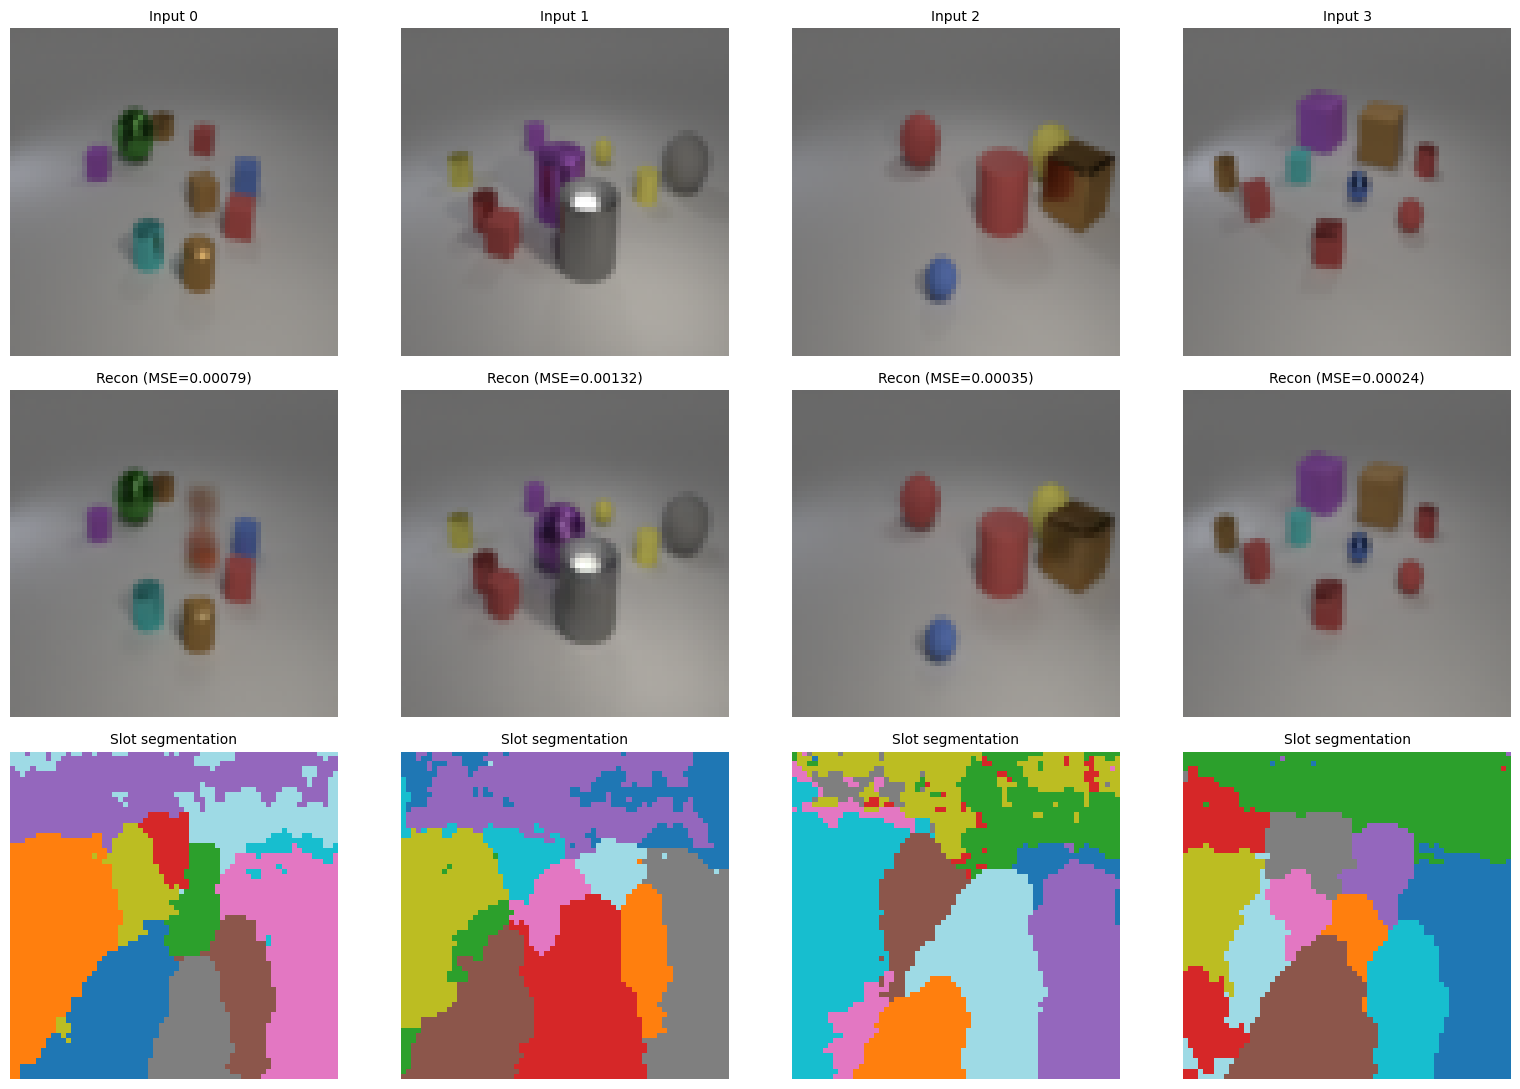

In [6]:
def to_img(t):
    """Convert [3, H, W] in [-1,1] to [H, W, 3] in [0,1]."""
    return np.clip((t.transpose(1, 2, 0) + 1) / 2, 0, 1)

recon_np = np.array(recon)
masks_np = np.array(masks)
imgs_np = np.array(images_jax)

B = imgs_np.shape[0]
N_slots = masks_np.shape[1]

slot_cmap = plt.cm.get_cmap("tab20", N_slots)
slot_colors = [slot_cmap(i)[:3] for i in range(N_slots)]

fig, axes = plt.subplots(3, B, figsize=(4 * B, 11))
if B == 1:
    axes = axes[:, None]

for j in range(B):
    axes[0, j].imshow(to_img(imgs_np[j]))
    axes[0, j].set_title(f"Input {j}", fontsize=10)
    axes[0, j].axis("off")

    axes[1, j].imshow(to_img(recon_np[j]))
    mse = float(((recon_np[j] - imgs_np[j]) ** 2).mean())
    axes[1, j].set_title(f"Recon (MSE={mse:.5f})", fontsize=10)
    axes[1, j].axis("off")

    seg = masks_np[j].argmax(axis=0)  # [H, W]
    seg_rgb = np.zeros((*seg.shape, 3))
    for s in range(N_slots):
        seg_rgb[seg == s] = slot_colors[s]
    axes[2, j].imshow(seg_rgb)
    axes[2, j].set_title("Slot segmentation", fontsize=10)
    axes[2, j].axis("off")

plt.tight_layout()
plt.show()

## 5. Per-slot mask detail (one image)

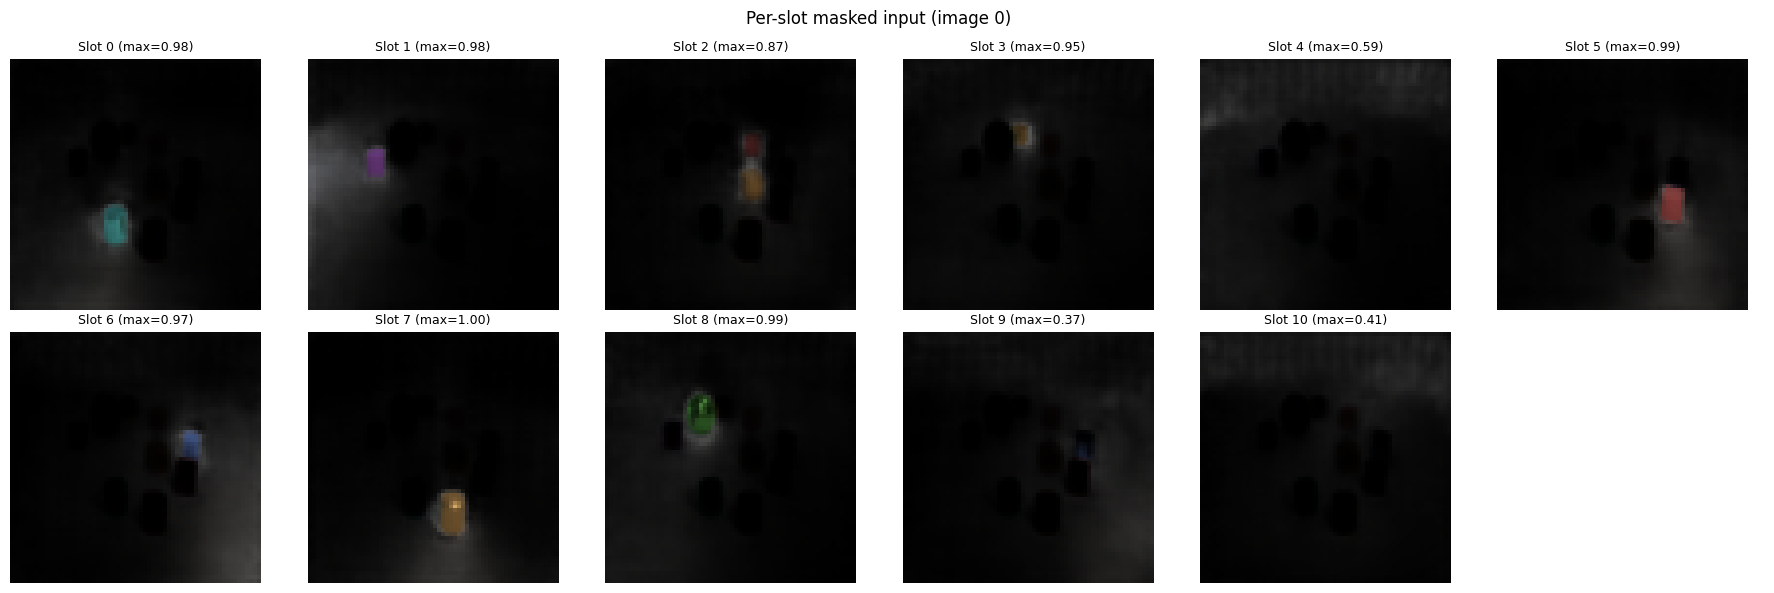

In [7]:
IMG_IDX = 0

n_cols = min(6, N_slots)
n_rows = (N_slots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
axes = np.array(axes).reshape(n_rows, n_cols)

for s in range(N_slots):
    r, c = divmod(s, n_cols)
    mask_s = masks_np[IMG_IDX, s]  # [H, W]
    masked_img = to_img(imgs_np[IMG_IDX]) * mask_s[..., None]
    axes[r, c].imshow(masked_img)
    axes[r, c].set_title(f"Slot {s} (max={mask_s.max():.2f})", fontsize=9)
    axes[r, c].axis("off")

for s in range(N_slots, n_rows * n_cols):
    r, c = divmod(s, n_cols)
    axes[r, c].axis("off")

fig.suptitle(f"Per-slot masked input (image {IMG_IDX})", fontsize=12)
plt.tight_layout()
plt.show()

## 6. Slot mask evolution across ODE time

We decode slot representations at intermediate ODE time steps to see how the masks sharpen.

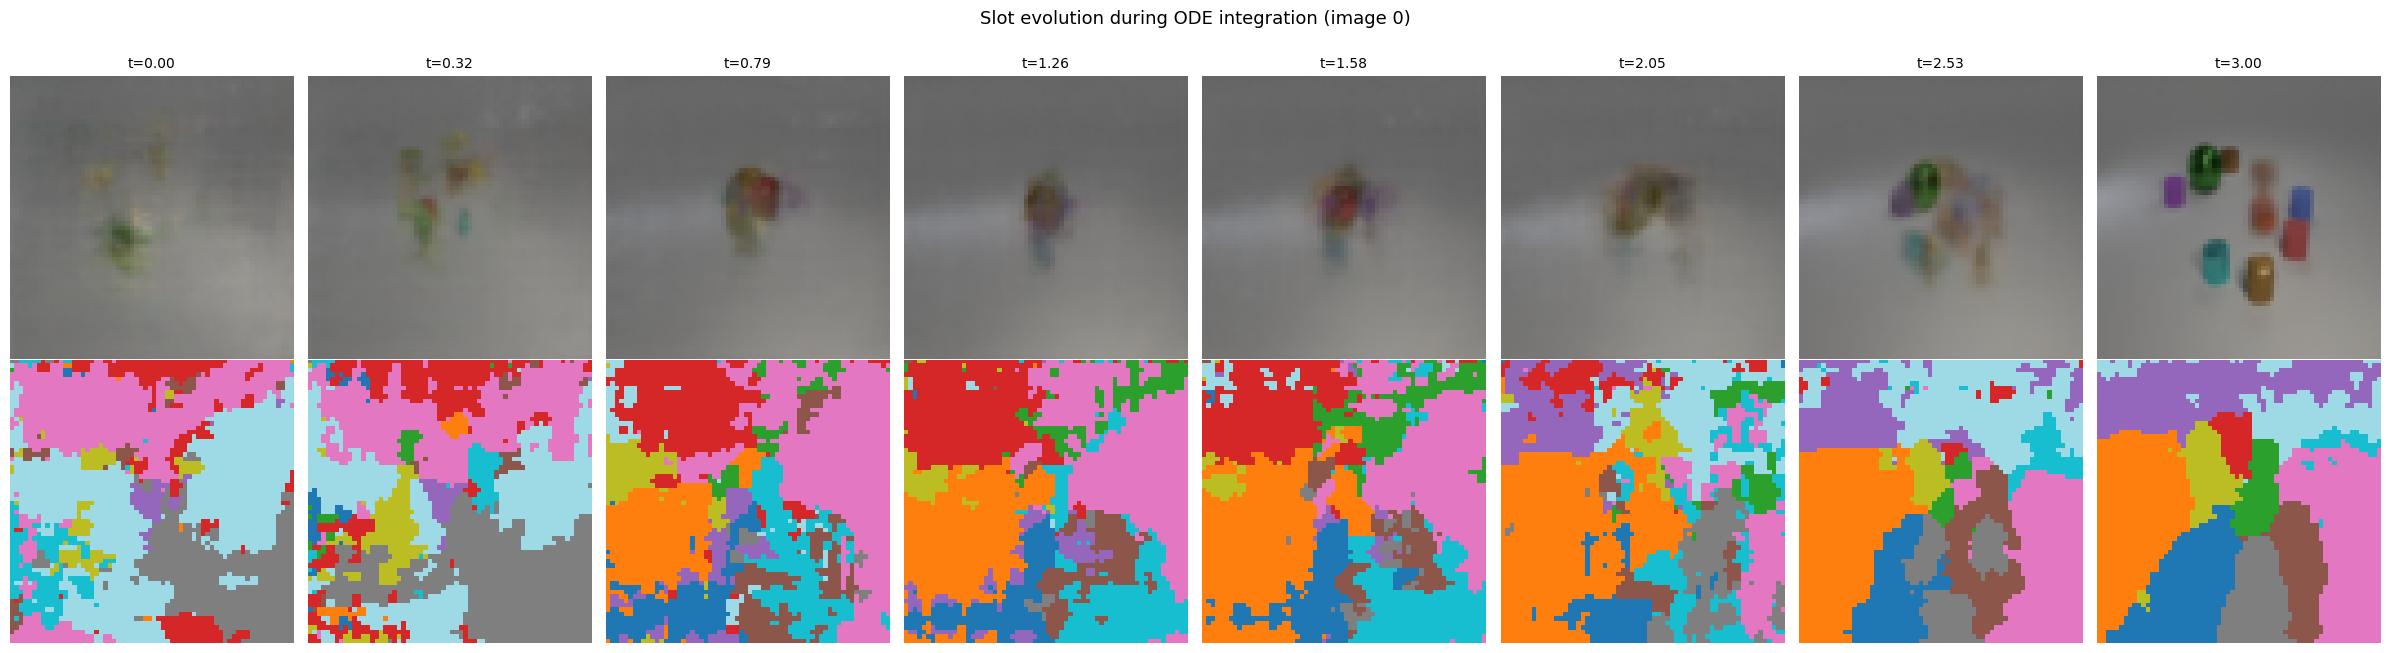

In [8]:
traj_np = np.array(traj)  # [T, B, N_slots, D_slot]
T_pts = traj_np.shape[0]

time_indices = np.linspace(0, T_pts - 1, 8, dtype=int)
T_show = float(model.slot_attention_ode.T)
time_values = np.linspace(0, T_show, T_pts)

@eqx.filter_jit
def decode_slots(model, slots):
    return model.dec(slots)

IMG_IDX = 0
n_time = len(time_indices)

fig, axes = plt.subplots(2, n_time, figsize=(3 * n_time, 6.5))

for col, ti in enumerate(time_indices):
    slots_t = jnp.array(traj_np[ti, IMG_IDX:IMG_IDX+1])  # [1, N_slots, D_slot]
    recon_t, masks_t = decode_slots(model, slots_t)
    recon_t_np = np.array(recon_t)
    masks_t_np = np.array(masks_t)

    axes[0, col].imshow(to_img(recon_t_np[0]))
    axes[0, col].set_title(f"t={time_values[ti]:.2f}", fontsize=10)
    axes[0, col].axis("off")

    seg = masks_t_np[0].argmax(axis=0)
    seg_rgb = np.zeros((*seg.shape, 3))
    for s in range(N_slots):
        seg_rgb[seg == s] = slot_colors[s]
    axes[1, col].imshow(seg_rgb)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Reconstruction", fontsize=10)
axes[1, 0].set_ylabel("Segmentation", fontsize=10)
fig.suptitle(f"Slot evolution during ODE integration (image {IMG_IDX})", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Per-slot mask sharpening over time

Track how individual slot masks evolve. For each active slot, show the mask at several time points.

Active slots (max mask > 0.15): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


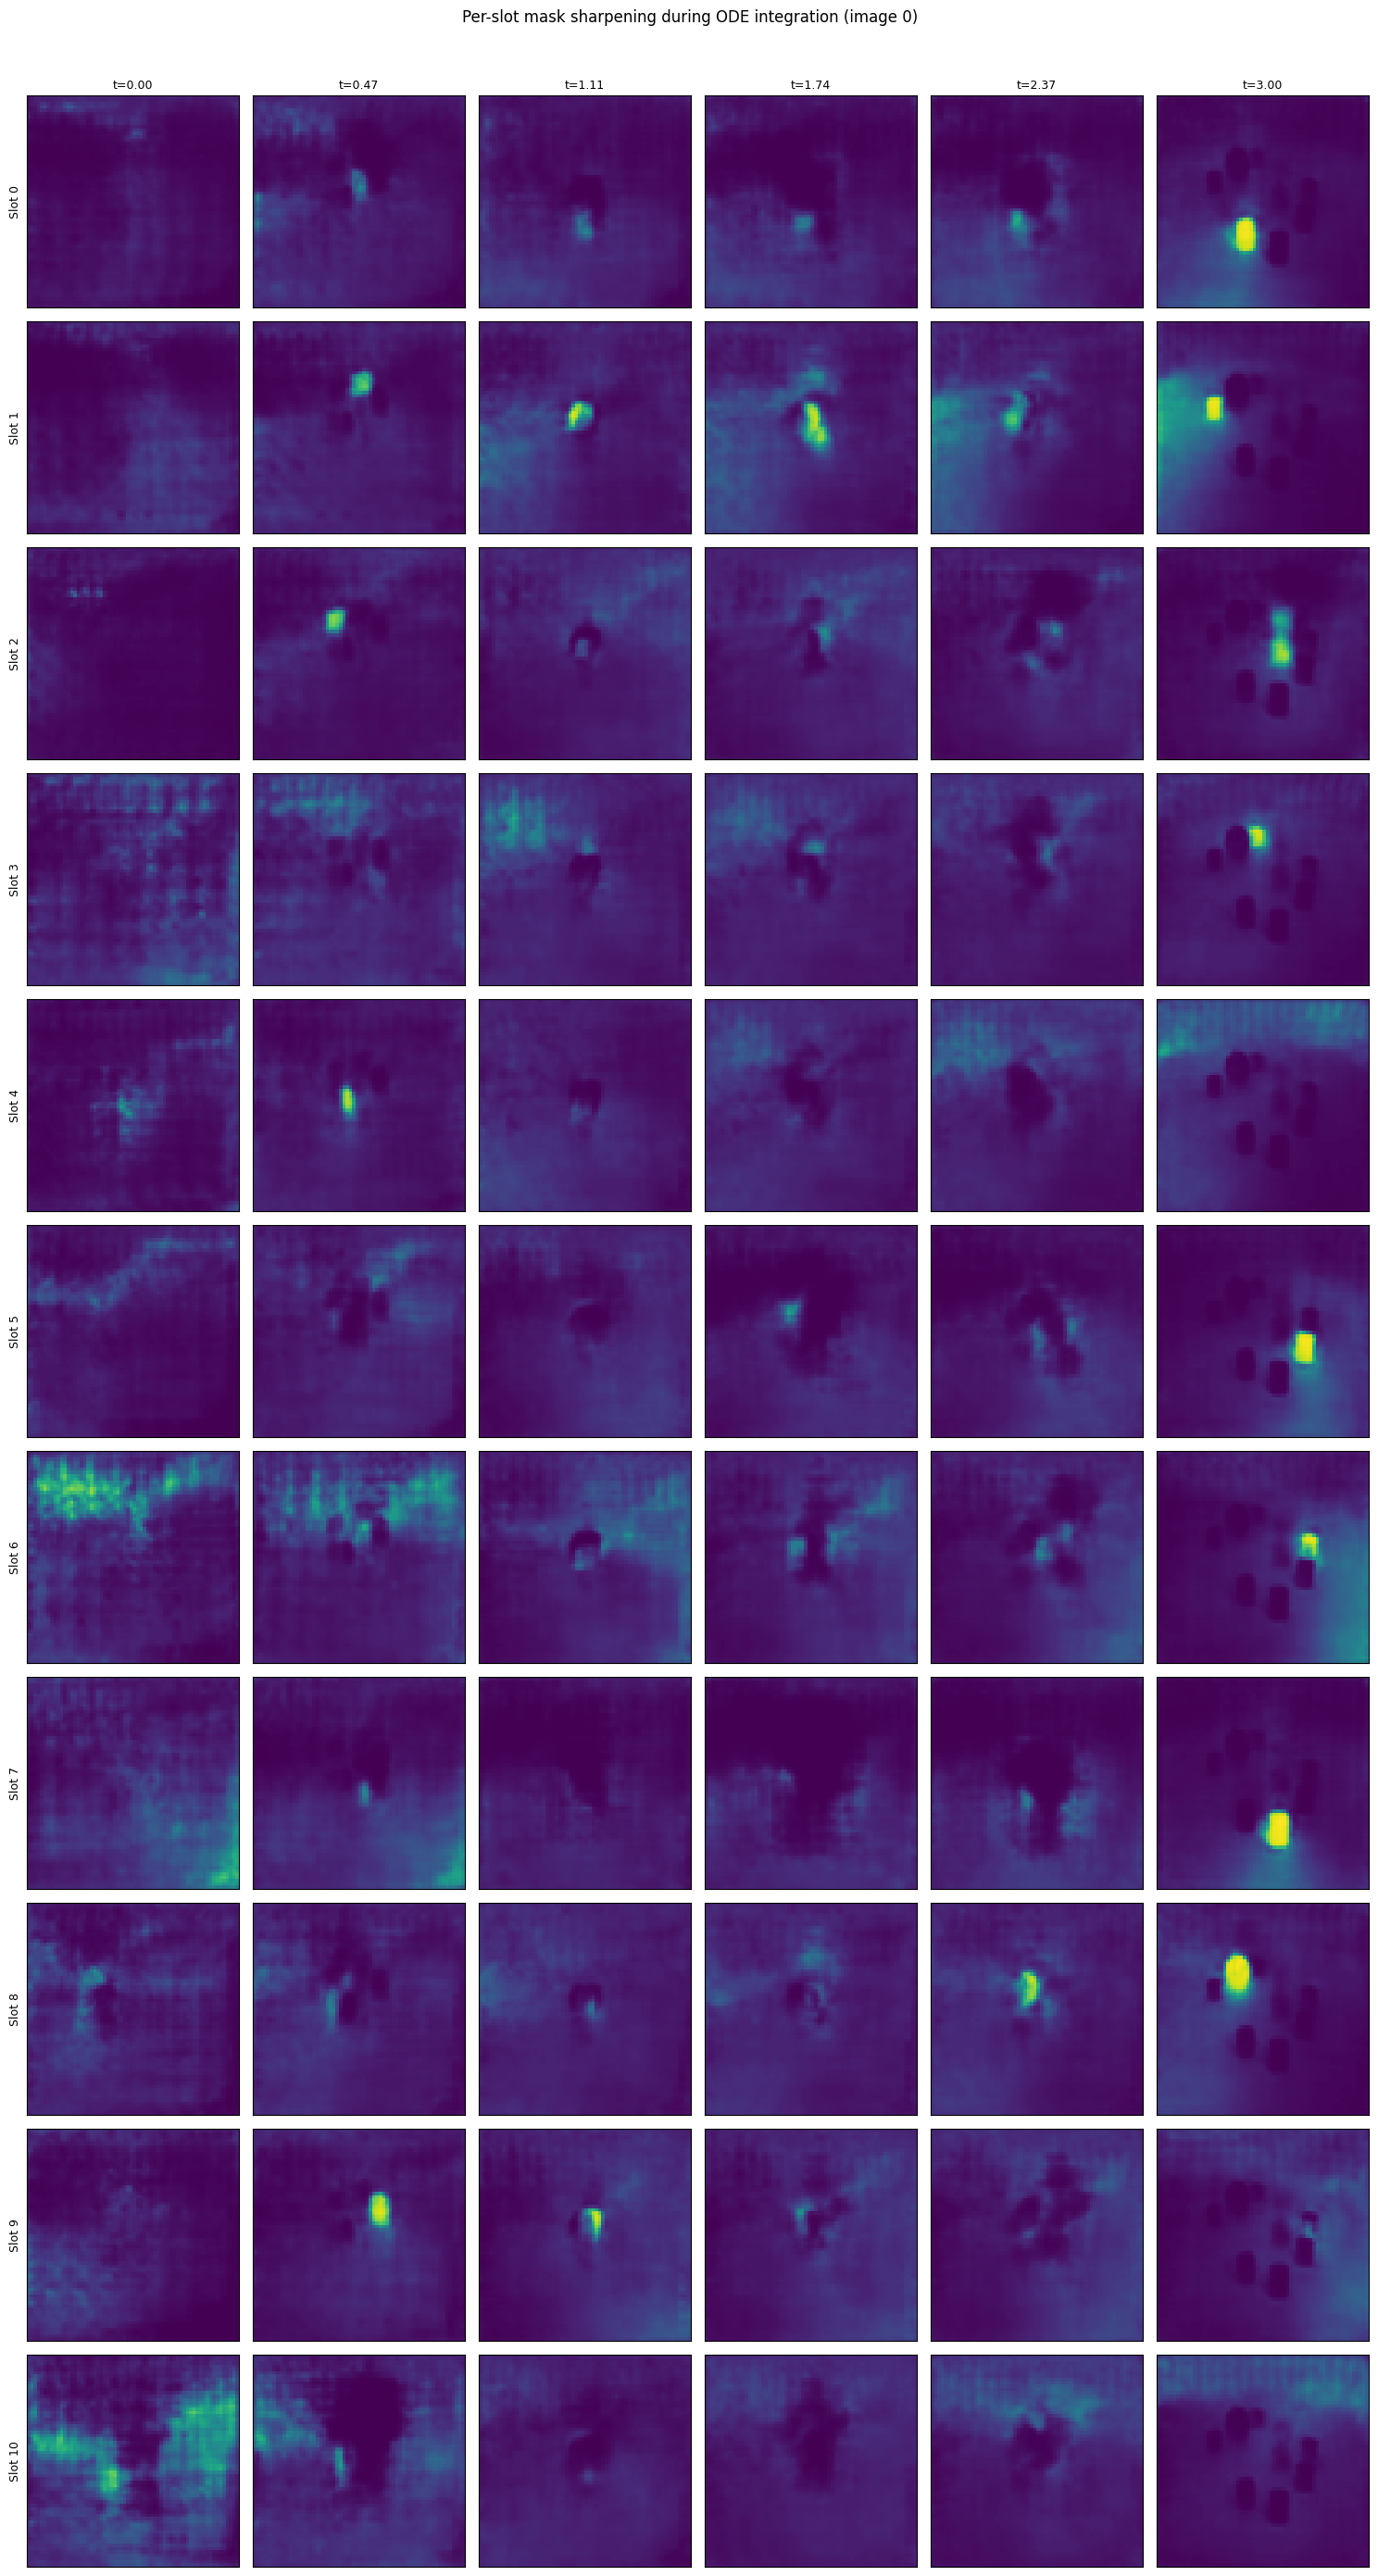

In [9]:
IMG_IDX = 0

final_masks = masks_np[IMG_IDX]  # [N_slots, H, W]
slot_activity = final_masks.max(axis=(1, 2))
active_slots = np.where(slot_activity > 0.15)[0]
print(f"Active slots (max mask > 0.15): {active_slots.tolist()}")

time_show = np.linspace(0, T_pts - 1, 6, dtype=int)

fig, axes = plt.subplots(len(active_slots), len(time_show),
                         figsize=(2.5 * len(time_show), 2.5 * len(active_slots)))
if len(active_slots) == 1:
    axes = axes[None, :]

for row, s in enumerate(active_slots):
    for col, ti in enumerate(time_show):
        slots_t = jnp.array(traj_np[ti, IMG_IDX:IMG_IDX+1])  # [1, N_slots, D]
        _, masks_t = decode_slots(model, slots_t)
        mask_s = np.array(masks_t[0, s])  # [H, W]

        axes[row, col].imshow(mask_s, cmap="viridis", vmin=0, vmax=1)
        if row == 0:
            axes[row, col].set_title(f"t={time_values[ti]:.2f}", fontsize=9)
        if col == 0:
            axes[row, col].set_ylabel(f"Slot {s}", fontsize=9)
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

fig.suptitle(f"Per-slot mask sharpening during ODE integration (image {IMG_IDX})", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 8. PCA of slot trajectories in latent space

Project the slot trajectories onto the first 2 principal components to visualize
how each slot's representation moves through latent space during integration.

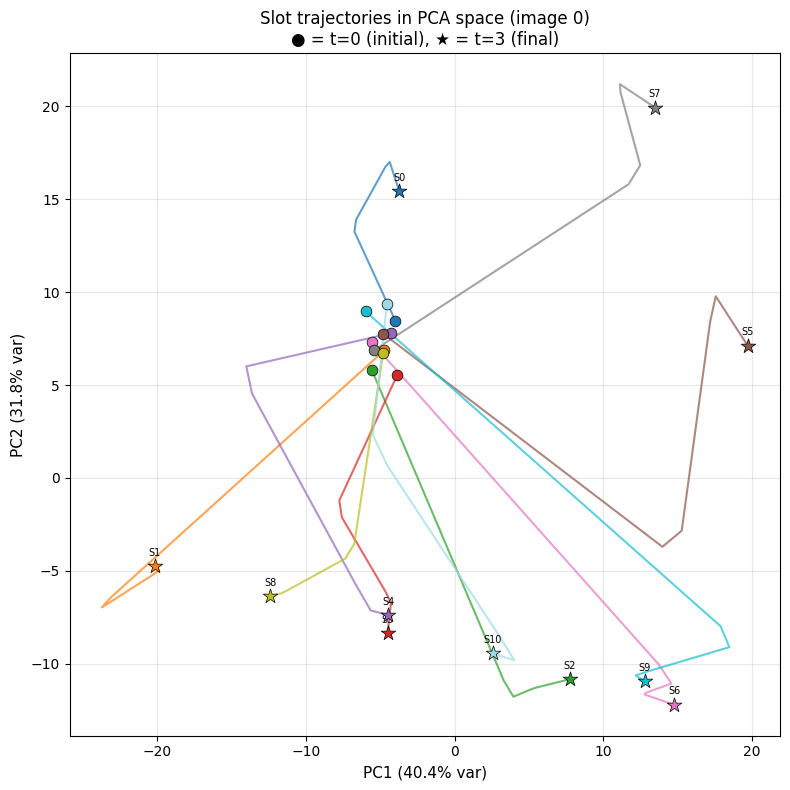

In [10]:
IMG_IDX = 0
traj_img = traj_np[:, IMG_IDX, :, :]  # [T, N_slots, D]
T_pts, N_s, D = traj_img.shape

all_pts = traj_img.reshape(-1, D)  # [T*N_slots, D]
pca = PCA(n_components=2)
pts_2d = pca.fit_transform(all_pts).reshape(T_pts, N_s, 2)  # [T, N_slots, 2]

fig, ax = plt.subplots(figsize=(8, 8))

for s in range(N_s):
    color = slot_colors[s]
    traj_s = pts_2d[:, s, :]  # [T, 2]
    ax.plot(traj_s[:, 0], traj_s[:, 1], color=color, alpha=0.7, linewidth=1.5)
    ax.scatter(traj_s[0, 0], traj_s[0, 1], color=color, marker="o", s=60,
              edgecolors="black", linewidths=0.5, zorder=5)
    ax.scatter(traj_s[-1, 0], traj_s[-1, 1], color=color, marker="*", s=120,
              edgecolors="black", linewidths=0.5, zorder=5)
    ax.annotate(f"S{s}", traj_s[-1], fontsize=7, ha="center", va="bottom",
               xytext=(0, 6), textcoords="offset points")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)", fontsize=11)
ax.set_title(f"Slot trajectories in PCA space (image {IMG_IDX})\n"
             f"● = t=0 (initial), ★ = t={T_show:.0f} (final)", fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Slot velocity magnitude over time

Shows how fast slots are moving at each point during integration. Convergence = velocity → 0.

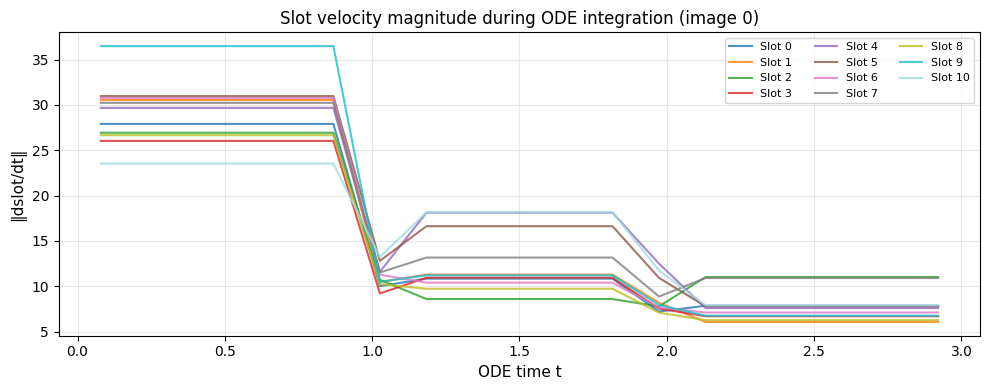

In [11]:
IMG_IDX = 0
traj_img = traj_np[:, IMG_IDX, :, :]  # [T, N_slots, D]

velocities = np.diff(traj_img, axis=0)  # [T-1, N_slots, D]
dt = time_values[1] - time_values[0]
speed = np.linalg.norm(velocities, axis=-1) / dt  # [T-1, N_slots]

fig, ax = plt.subplots(figsize=(10, 4))
t_mid = (time_values[:-1] + time_values[1:]) / 2

for s in range(N_s):
    label = f"Slot {s}" if slot_activity[s] > 0.15 else None
    alpha = 0.8 if slot_activity[s] > 0.15 else 0.2
    ax.plot(t_mid, speed[:, s], color=slot_colors[s], alpha=alpha, linewidth=1.5, label=label)

ax.set_xlabel("ODE time t", fontsize=11)
ax.set_ylabel("‖dslot/dt‖", fontsize=11)
ax.set_title(f"Slot velocity magnitude during ODE integration (image {IMG_IDX})", fontsize=12)
ax.legend(fontsize=8, ncol=3, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Spectral dynamics of the QK pair (DiffEqFormer-style analysis)

Following Tong et al. 2025 (DiffEqFormer, Section 5.1, Figure 2a), we analyze the spectral flow
of the **QK product** M(t) = W_q(t)^T @ W_k, where W_k is the fixed key projection.

The attention logit is `s_i^T M(t) f_j / sqrt(d)` — so eigenvalues of M(t) directly control:
- **Attention sharpness**: Var(s^T M f) = trace(M^T M) = Σ λ_i². Larger eigenvalues → sharper (more one-hot) attention.
- **Interaction strength**: The range of eigenvalues determines how discriminatively slots attend to features.

The paper finds that trained DiffEqFormers exhibit *increasing* eigenvalue magnitudes toward later layers,
preventing the clustering behavior predicted by weight-sharing theories (Geshkovski et al. 2023).

In [12]:
N_TIME = 200
T_max = float(model.slot_attention_ode.T)
ts = np.linspace(0, T_max, N_TIME)

tdw_q = model.slot_attention_ode.slot_ode_func.tdw_q
W_k = np.array(model.slot_attention_ode.to_k.weight)  # [slot_dim, slot_dim]

@jax.jit
def get_Wq(t):
    return tdw_q(t)

Wq_stack = np.stack([np.array(get_Wq(float(t))) for t in ts])  # [N_TIME, d, d]
print(f"W_q(t) shape: {Wq_stack[0].shape}, W_k shape: {W_k.shape}")

# QK product: M(t) = W_q(t)^T @ W_k  (the paper's Q(t)^T K(t) analogue)
# att_logit = s^T W_q^T W_k f / sqrt(d), so M = W_q^T @ W_k
QK_stack = np.array([Wq.T @ W_k for Wq in Wq_stack])  # [N_TIME, d, d]

eigs_Wq = np.array([np.linalg.eigvals(W) for W in Wq_stack])
eigs_QK = np.array([np.linalg.eigvals(M) for M in QK_stack])
print(f"Eigenvalues computed: W_q {eigs_Wq.shape}, QK {eigs_QK.shape}")

W_q(t) shape: (64, 64), W_k shape: (64, 64)
Eigenvalues computed: W_q (200, 64), QK (200, 64)


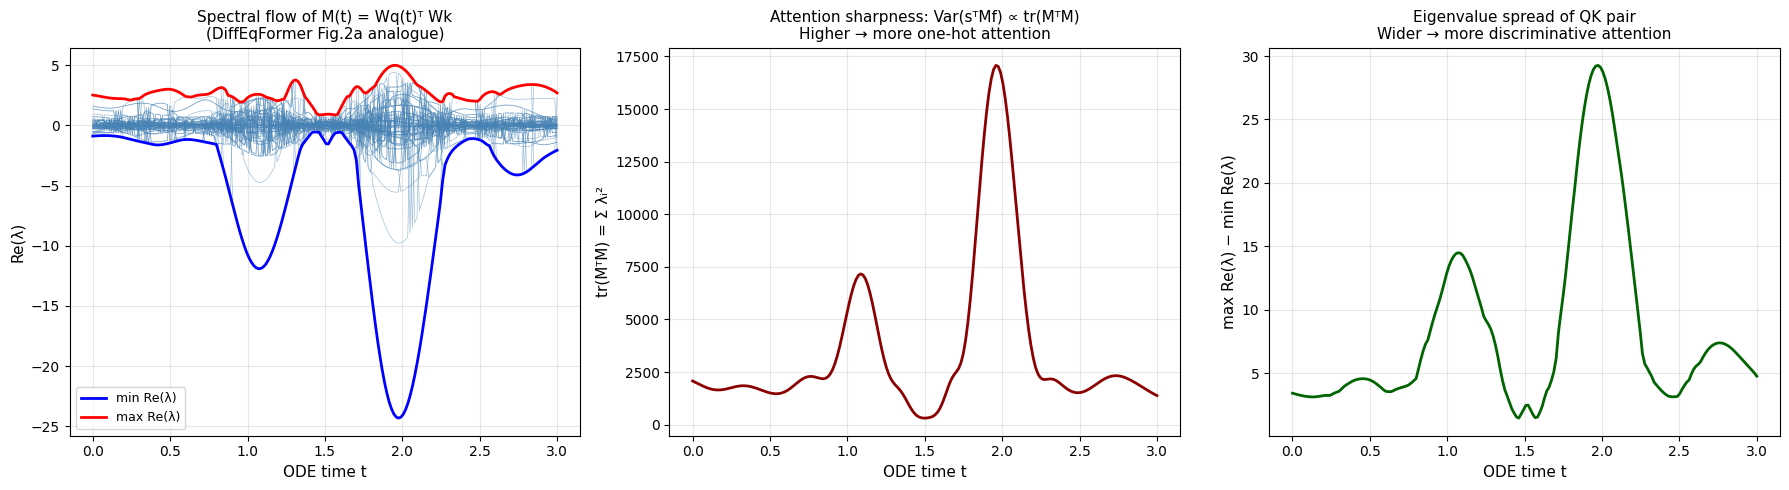

In [13]:
# --- Figure 2a analogue: spectral flow of Re(λ) for QK pair ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
reals_QK = eigs_QK.real  # [N_TIME, d]
for k in range(reals_QK.shape[1]):
    ax.plot(ts, reals_QK[:, k], linewidth=0.5, alpha=0.5, color="steelblue")
sorted_reals = np.sort(reals_QK, axis=1)
for k, label in [(0, "min Re(λ)"), (-1, "max Re(λ)")]:
    ax.plot(ts, sorted_reals[:, k], linewidth=2.0, color="red" if k == -1 else "blue", label=label)
ax.set_xlabel("ODE time t", fontsize=11)
ax.set_ylabel("Re(λ)", fontsize=11)
ax.set_title("Spectral flow of M(t) = Wq(t)ᵀ Wk\n(DiffEqFormer Fig.2a analogue)", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- attention sharpness: trace(M^T M) = sum λ_i^2 ---
ax = axes[1]
trace_MtM = np.array([np.trace(M.T @ M) for M in QK_stack])
ax.plot(ts, trace_MtM, linewidth=2.0, color="darkred")
ax.set_xlabel("ODE time t", fontsize=11)
ax.set_ylabel("tr(MᵀM) = Σ λᵢ²", fontsize=11)
ax.set_title("Attention sharpness: Var(sᵀMf) ∝ tr(MᵀM)\nHigher → more one-hot attention", fontsize=11)
ax.grid(True, alpha=0.3)

# --- eigenvalue spread (max - min) ---
ax = axes[2]
eig_range = sorted_reals[:, -1] - sorted_reals[:, 0]
ax.plot(ts, eig_range, linewidth=2.0, color="darkgreen")
ax.set_xlabel("ODE time t", fontsize=11)
ax.set_ylabel("max Re(λ) − min Re(λ)", fontsize=11)
ax.set_title("Eigenvalue spread of QK pair\nWider → more discriminative attention", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

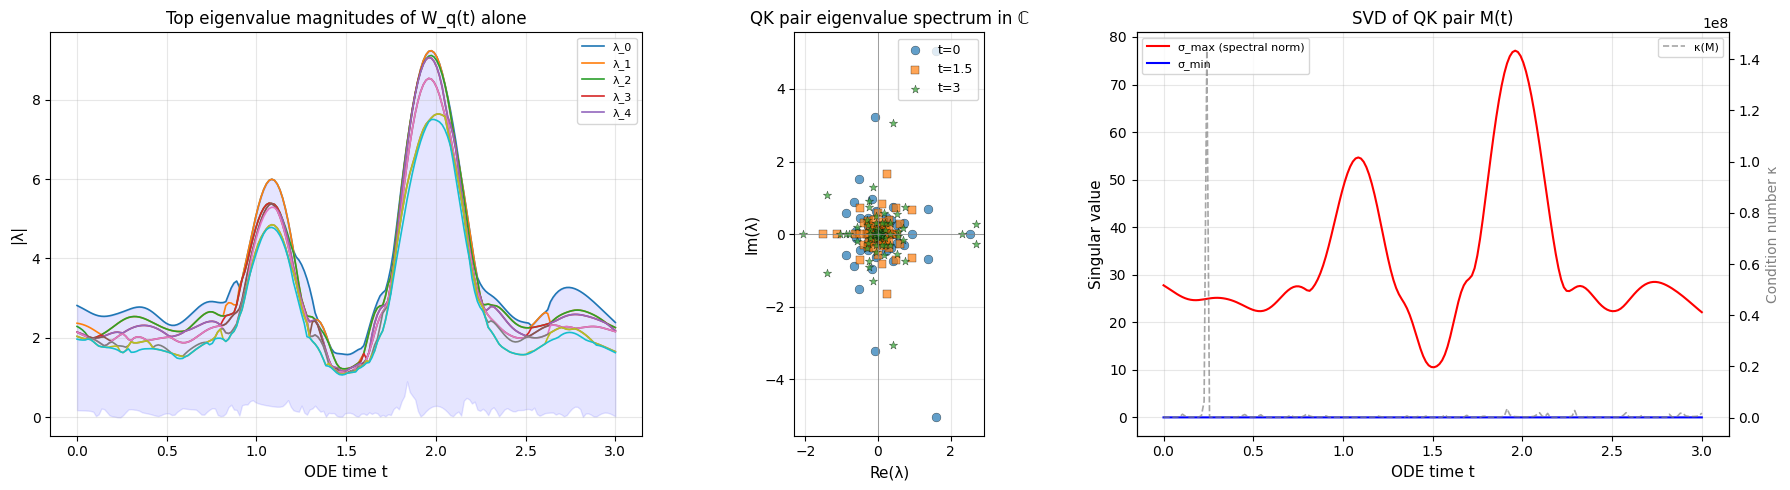

In [14]:
# --- W_q(t) eigenvalue magnitudes (standalone, not QK product) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
mags = np.abs(eigs_Wq)
sorted_mags = np.sort(mags, axis=1)[:, ::-1]
for k in range(min(10, sorted_mags.shape[1])):
    ax.plot(ts, sorted_mags[:, k], linewidth=1.2, label=f"λ_{k}" if k < 5 else None)
ax.fill_between(ts, sorted_mags.min(axis=1), sorted_mags.max(axis=1), alpha=0.1, color="blue")
ax.set_xlabel("ODE time t", fontsize=11)
ax.set_ylabel("|λ|", fontsize=11)
ax.set_title("Top eigenvalue magnitudes of W_q(t) alone", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- QK pair eigenvalue spectrum in complex plane ---
ax = axes[1]
for t_val, marker, label in [(0, "o", "t=0"), (T_max/2, "s", f"t={T_max/2:.1f}"), (T_max, "*", f"t={T_max:.0f}")]:
    idx = np.argmin(np.abs(ts - t_val))
    e = eigs_QK[idx]
    ax.scatter(e.real, e.imag, marker=marker, s=40, alpha=0.7, label=label, edgecolors="black", linewidths=0.3)
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set_xlabel("Re(λ)", fontsize=11)
ax.set_ylabel("Im(λ)", fontsize=11)
ax.set_title("QK pair eigenvalue spectrum in ℂ", fontsize=12)
ax.legend(fontsize=9)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

# --- spectral norm + condition number of QK pair ---
ax = axes[2]
svds_QK = np.array([np.linalg.svd(M, compute_uv=False) for M in QK_stack])
ax.plot(ts, svds_QK[:, 0], linewidth=1.5, label="σ_max (spectral norm)", color="red")
ax.plot(ts, svds_QK[:, -1], linewidth=1.5, label="σ_min", color="blue")
ax2 = ax.twinx()
cond_QK = svds_QK[:, 0] / (svds_QK[:, -1] + 1e-12)
ax2.plot(ts, cond_QK, linewidth=1.2, linestyle="--", color="gray", alpha=0.7, label="κ(M)")
ax2.set_ylabel("Condition number κ", fontsize=10, color="gray")
ax.set_xlabel("ODE time t", fontsize=11)
ax.set_ylabel("Singular value", fontsize=11)
ax.set_title("SVD of QK pair M(t)", fontsize=12)
ax.legend(fontsize=8, loc="upper left")
ax2.legend(fontsize=8, loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Spectral norm of all time-dependent weight matrices

Compare the spectral norm ‖W(t)‖₂ across Q, Gate, FF₀, FF₁ to see which components are most active at each time.

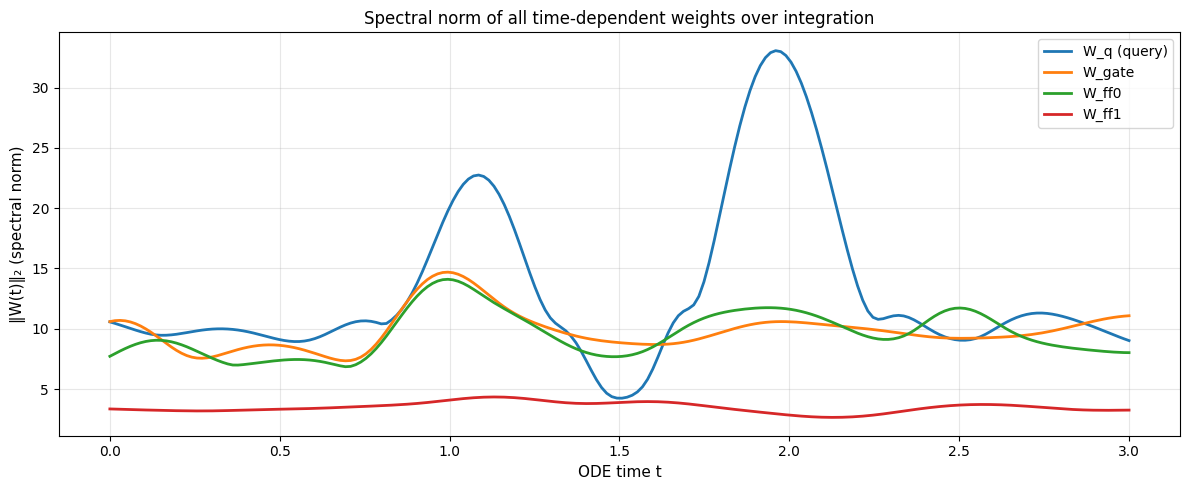

In [15]:
ode_func = model.slot_attention_ode.slot_ode_func
tdws = {
    "W_q (query)": ode_func.tdw_q,
    "W_gate": ode_func.tdw_gate,
    "W_ff0": ode_func.tdw_ff0,
    "W_ff1": ode_func.tdw_ff1,
}

@jax.jit
def get_weight(tdw, t):
    return tdw(t)

spectral_norms = {}
for name, tdw in tdws.items():
    norms = []
    for t in ts:
        W = np.array(get_weight(tdw, float(t)))
        norms.append(np.linalg.svd(W, compute_uv=False)[0])
    spectral_norms[name] = np.array(norms)

fig, ax = plt.subplots(figsize=(12, 5))
for name, norms in spectral_norms.items():
    ax.plot(ts, norms, linewidth=2.0, label=name)
ax.set_xlabel("ODE time t", fontsize=11)
ax.set_ylabel("‖W(t)‖₂ (spectral norm)", fontsize=11)
ax.set_title("Spectral norm of all time-dependent weights over integration", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Stability analysis & attractors

### 12a. Jacobian eigenvalues along the trajectory

For a non-autonomous ODE ẋ = f(t, x, args), local stability is determined by the Jacobian
J(t) = ∂f/∂x evaluated along the trajectory. If Re(λ_i(J)) < 0 at a point, the flow is locally
contracting there (attracting). If Re(λ_i(J)) > 0, it's locally expanding (repelling).

We compute J at several time points by differentiating the ODE vector field w.r.t. the slot state.

In [16]:
IMG_IDX = 0

enc_feat = model.enc(images_jax)
feat_norm = jax.vmap(jax.vmap(model.slot_attention_ode.norm_input))(enc_feat)
feat = jax.vmap(jax.vmap(model.slot_attention_ode.fc_input))(feat_norm)
k_feat = jax.vmap(jax.vmap(model.slot_attention_ode.to_k))(feat)
v_feat = jax.vmap(jax.vmap(model.slot_attention_ode.to_v))(feat)

k_single = k_feat[IMG_IDX:IMG_IDX+1]  # [1, N_feat, D]
v_single = v_feat[IMG_IDX:IMG_IDX+1]  # [1, N_feat, D]

ode_func = model.slot_attention_ode.slot_ode_func

def velocity_flat(slots_flat, t):
    """ODE velocity for a single image, flattened slots."""
    slots = slots_flat.reshape(1, N_slots, -1)
    vel = ode_func(t, slots, (k_single, v_single))
    return vel.reshape(-1)

@jax.jit
def jacobian_eigs_at(slots_flat, t):
    J = jax.jacobian(velocity_flat)(slots_flat, t)  # [N_slots*D, N_slots*D]
    return J

n_jac_pts = 15
jac_time_indices = np.linspace(0, T_pts - 1, n_jac_pts, dtype=int)

jac_eigs_list = []
jac_traces = []
for ti in jac_time_indices:
    slots_t = traj_np[ti, IMG_IDX]  # [N_slots, D]
    slots_flat = jnp.array(slots_t.reshape(-1))
    t_val = time_values[ti]

    J = np.array(jacobian_eigs_at(slots_flat, t_val))
    eig_vals = np.linalg.eigvals(J)
    jac_eigs_list.append(eig_vals)
    jac_traces.append(np.trace(J))
    print(f"  t={t_val:.2f}: max Re(λ)={eig_vals.real.max():.3f}, "
          f"min Re(λ)={eig_vals.real.min():.3f}, tr(J)={np.trace(J).real:.3f}")

print(f"\nJacobian size: {J.shape} ({N_slots}×{slots.shape[-1]} = {N_slots * slots.shape[-1]} dims)")

E0317 18:51:03.309251  311185 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0317 18:51:03.459589  311200 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  t=0.00: max Re(λ)=13.854, min Re(λ)=-2.218, tr(J)=-621.785
  t=0.16: max Re(λ)=1.784, min Re(λ)=-9.112, tr(J)=-783.943
  t=0.32: max Re(λ)=1.349, min Re(λ)=-5.987, tr(J)=-627.183
  t=0.63: max Re(λ)=0.435, min Re(λ)=-1.568, tr(J)=-358.299
  t=0.79: max Re(λ)=0.310, min Re(λ)=-2.987, tr(J)=-454.553
  t=0.95: max Re(λ)=1.556, min Re(λ)=-1.434, tr(J)=-593.704
  t=1.26: max Re(λ)=0.840, min Re(λ)=-1.125, tr(J)=-385.061
  t=1.42: max Re(λ)=0.091, min Re(λ)=-6.261, tr(J)=-303.833
  t=1.58: max Re(λ)=2.232, min Re(λ)=-4.768, tr(J)=-380.816
  t=1.89: max Re(λ)=2.771, min Re(λ)=-1.381, tr(J)=-383.646
  t=2.05: max Re(λ)=6.137, min Re(λ)=-1.219, tr(J)=-311.243
  t=2.21: max Re(λ)=1.131, min Re(λ)=-1.484, tr(J)=-302.181
  t=2.53: max Re(λ)=7.160, min Re(λ)=-7.448, tr(J)=-460.222
  t=2.68: max Re(λ)=9.069, min Re(λ)=-9.030, tr(J)=-350.301
  t=3.00: max Re(λ)=2.464, min Re(λ)=-1.823, tr(J)=-258.265

Jacobian size: (704, 704) (11×64 = 704 dims)


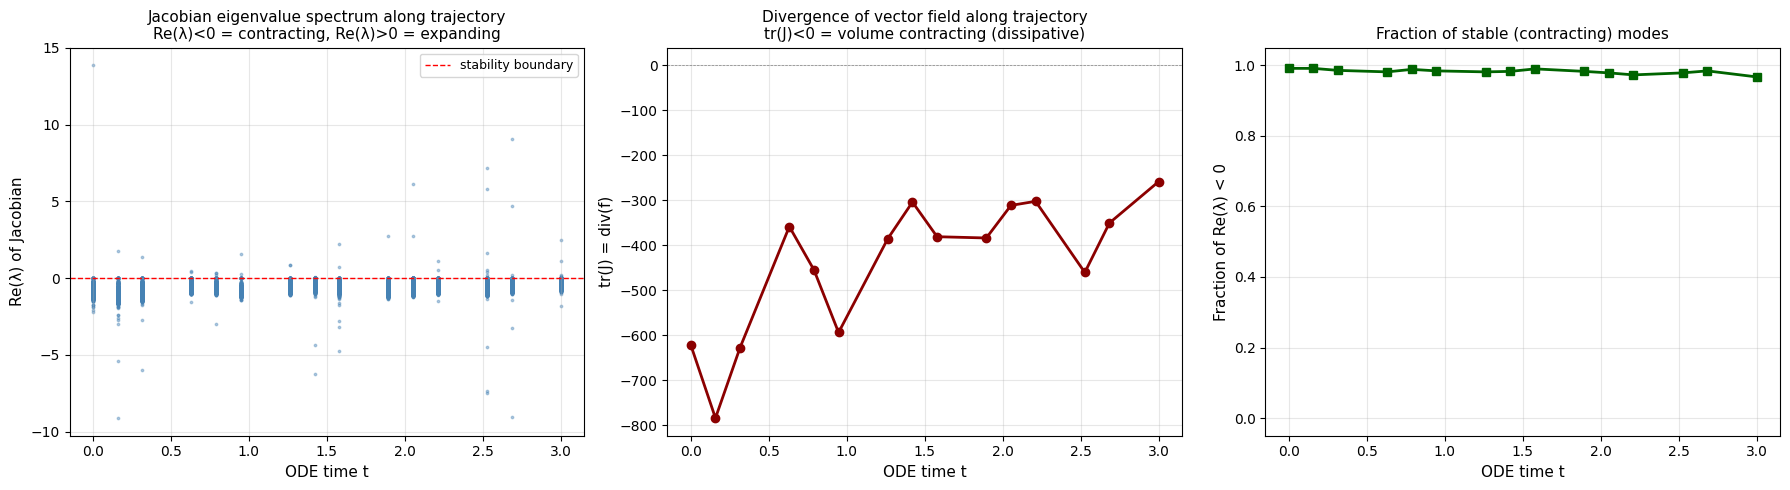

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Re(λ) of Jacobian over time ---
ax = axes[0]
for i, ti in enumerate(jac_time_indices):
    t_val = time_values[ti]
    eigs = jac_eigs_list[i]
    ax.scatter(np.full_like(eigs.real, t_val), eigs.real, s=3, alpha=0.4, color="steelblue")
ax.axhline(0, color="red", linewidth=1, linestyle="--", label="stability boundary")
ax.set_xlabel("ODE time t", fontsize=11)
ax.set_ylabel("Re(λ) of Jacobian", fontsize=11)
ax.set_title("Jacobian eigenvalue spectrum along trajectory\nRe(λ)<0 = contracting, Re(λ)>0 = expanding", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- trace(J) over time = divergence of vector field ---
ax = axes[1]
t_jac = [time_values[ti] for ti in jac_time_indices]
ax.plot(t_jac, [tr.real for tr in jac_traces], "o-", linewidth=2, color="darkred", markersize=6)
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.set_xlabel("ODE time t", fontsize=11)
ax.set_ylabel("tr(J) = div(f)", fontsize=11)
ax.set_title("Divergence of vector field along trajectory\ntr(J)<0 = volume contracting (dissipative)", fontsize=11)
ax.grid(True, alpha=0.3)

# --- fraction of eigenvalues with Re(λ) < 0 ---
ax = axes[2]
frac_stable = [np.mean(e.real < 0) for e in jac_eigs_list]
ax.plot(t_jac, frac_stable, "s-", linewidth=2, color="darkgreen", markersize=6)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("ODE time t", fontsize=11)
ax.set_ylabel("Fraction of Re(λ) < 0", fontsize=11)
ax.set_title("Fraction of stable (contracting) modes", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 12b. Basin of attraction — convergence from different initializations

Run the model from many different random seeds (different slot initializations) on the same image.
If final slots converge to similar representations (up to permutation), the system has a strong attractor.

In [18]:
N_SEEDS = 20
IMG_IDX = 0
single_img = images_jax[IMG_IDX:IMG_IDX+1]  # [1, 3, H, W]

@eqx.filter_jit
def forward_single(model, img, key):
    recon, masks, slots = model(img, key=key)
    return slots, masks

all_final_slots = []
all_final_masks = []
for seed in range(N_SEEDS):
    s, m = forward_single(model, single_img, jax.random.key(seed))
    all_final_slots.append(np.array(s[0]))   # [N_slots, D]
    all_final_masks.append(np.array(m[0]))    # [N_slots, H, W]

all_final_slots = np.stack(all_final_slots)  # [N_SEEDS, N_slots, D]
all_final_masks = np.stack(all_final_masks)  # [N_SEEDS, N_slots, H, W]
print(f"Collected {N_SEEDS} runs, slots shape: {all_final_slots.shape}")

Collected 20 runs, slots shape: (20, 11, 64)


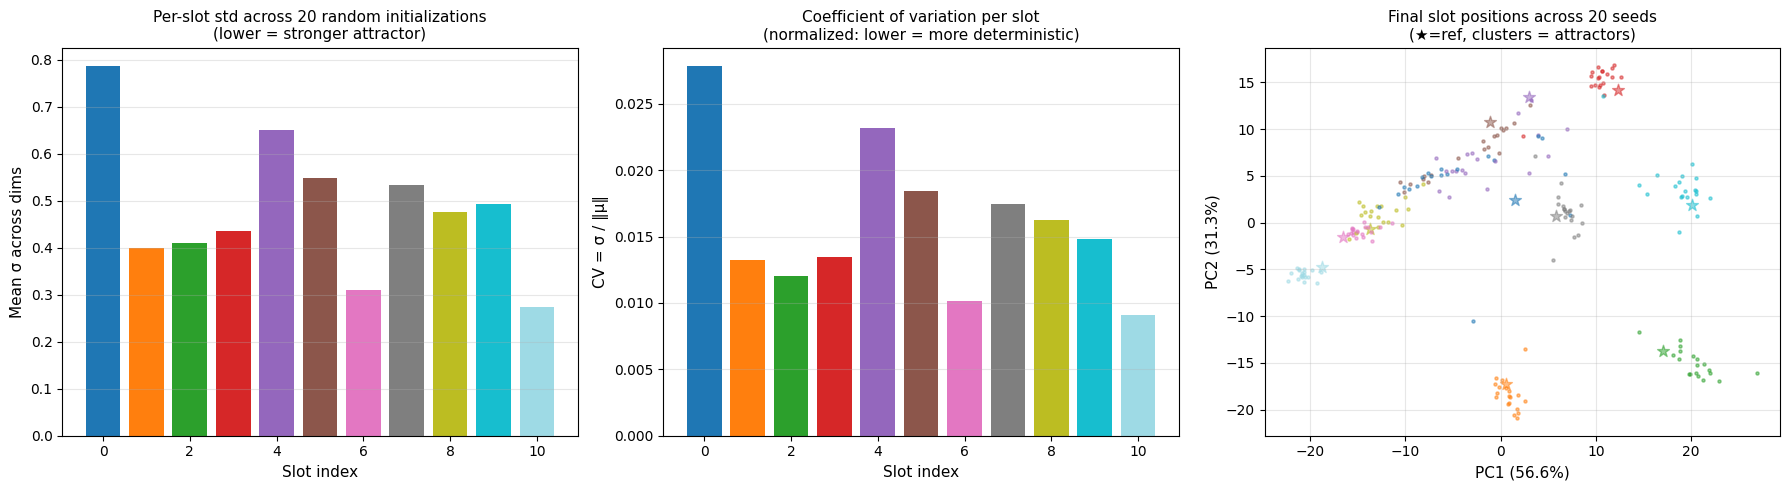

In [19]:
from scipy.optimize import linear_sum_assignment

def hungarian_match_slots(ref_slots, target_slots):
    """Match target slots to ref slots via Hungarian algorithm on cosine distance."""
    ref_norm = ref_slots / (np.linalg.norm(ref_slots, axis=-1, keepdims=True) + 1e-8)
    tgt_norm = target_slots / (np.linalg.norm(target_slots, axis=-1, keepdims=True) + 1e-8)
    cost = 1 - ref_norm @ tgt_norm.T  # [N, N] cosine distance
    row_ind, col_ind = linear_sum_assignment(cost)
    return col_ind  # permutation: target[col_ind[i]] matches ref[i]

ref_slots = all_final_slots[0]  # use seed 0 as reference
aligned_slots = [ref_slots]
for i in range(1, N_SEEDS):
    perm = hungarian_match_slots(ref_slots, all_final_slots[i])
    aligned_slots.append(all_final_slots[i][perm])
aligned_slots = np.stack(aligned_slots)  # [N_SEEDS, N_slots, D]

slot_std = aligned_slots.std(axis=0)  # [N_slots, D]
slot_mean_std = slot_std.mean(axis=-1)  # [N_slots]
slot_rep_norm = np.linalg.norm(aligned_slots.mean(axis=0), axis=-1)  # [N_slots]
coeff_of_variation = slot_mean_std / (slot_rep_norm + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.bar(range(N_slots), slot_mean_std, color=[slot_colors[s] for s in range(N_slots)])
ax.set_xlabel("Slot index", fontsize=11)
ax.set_ylabel("Mean σ across dims", fontsize=11)
ax.set_title(f"Per-slot std across {N_SEEDS} random initializations\n(lower = stronger attractor)", fontsize=11)
ax.grid(True, alpha=0.3, axis="y")

ax = axes[1]
ax.bar(range(N_slots), coeff_of_variation, color=[slot_colors[s] for s in range(N_slots)])
ax.set_xlabel("Slot index", fontsize=11)
ax.set_ylabel("CV = σ / ‖μ‖", fontsize=11)
ax.set_title("Coefficient of variation per slot\n(normalized: lower = more deterministic)", fontsize=11)
ax.grid(True, alpha=0.3, axis="y")

# PCA of all final slots from all seeds together
ax = axes[2]
all_flat = aligned_slots.reshape(-1, aligned_slots.shape[-1])  # [N_SEEDS*N_slots, D]
pca_basin = PCA(n_components=2)
pts_2d = pca_basin.fit_transform(all_flat).reshape(N_SEEDS, N_slots, 2)
for seed in range(N_SEEDS):
    for s in range(N_slots):
        marker = "*" if seed == 0 else "."
        size = 80 if seed == 0 else 20
        ax.scatter(pts_2d[seed, s, 0], pts_2d[seed, s, 1],
                  color=slot_colors[s], marker=marker, s=size, alpha=0.5)
ax.set_xlabel(f"PC1 ({pca_basin.explained_variance_ratio_[0]:.1%})", fontsize=11)
ax.set_ylabel(f"PC2 ({pca_basin.explained_variance_ratio_[1]:.1%})", fontsize=11)
ax.set_title(f"Final slot positions across {N_SEEDS} seeds\n(★=ref, clusters = attractors)", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 12c. Perturbation growth — Lyapunov-style analysis

Perturb the initial slots by small ε in random directions, run the ODE, and track
how ‖x_perturbed(t) − x_reference(t)‖ evolves. Exponential decay = stable attractor.
The growth rate λ ≈ (1/t) log(‖δx(t)‖ / ‖δx(0)‖) is the finite-time Lyapunov exponent.

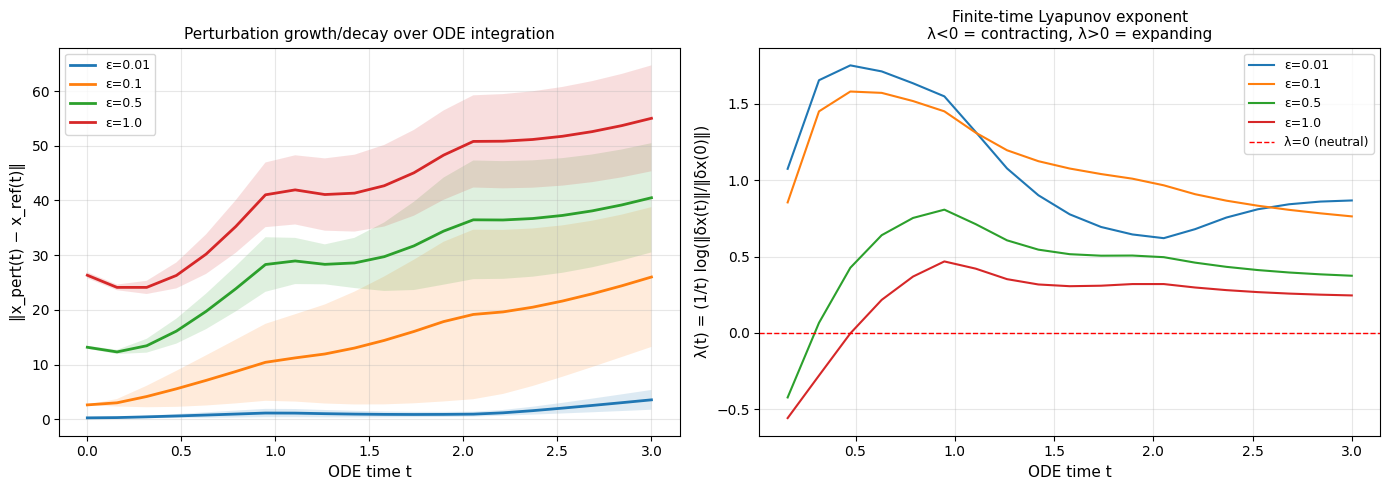

In [20]:
N_PERTURB = 10
EPSILONS = [0.01, 0.1, 0.5, 1.0]
IMG_IDX = 0

@eqx.filter_jit
def forward_traj_single(model, img, key):
    return model(img, key=key, return_traj=True)

ref_key = jax.random.key(42)
_, _, _, ref_traj = forward_traj_single(model, single_img, ref_key)
ref_traj_np = np.array(ref_traj[:, 0])  # [T, N_slots, D]
N_TRAJ = ref_traj_np.shape[0]
tvals_pert = np.linspace(0, T_show, N_TRAJ)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for eps in EPSILONS:
    all_separations = []
    for p in range(N_PERTURB):
        pert_key = jax.random.key(1000 + p)
        k1, k2 = jax.random.split(pert_key)

        # perturb the slot initialization by injecting noise into the key
        # we manually create perturbed initial slots and run the ODE
        enc_feat_s = model.enc(single_img)
        feat_norm_s = jax.vmap(jax.vmap(model.slot_attention_ode.norm_input))(enc_feat_s)
        feat_s = jax.vmap(jax.vmap(model.slot_attention_ode.fc_input))(feat_norm_s)
        k_s = jax.vmap(jax.vmap(model.slot_attention_ode.to_k))(feat_s)
        v_s = jax.vmap(jax.vmap(model.slot_attention_ode.to_v))(feat_s)

        slots_ref = model.slot_attention_ode.initialize_slots(1, ref_key)
        noise = eps * jax.random.normal(k2, slots_ref.shape)
        slots_pert = slots_ref + noise

        sa = model.slot_attention_ode
        term = diffrax.ODETerm(sa.slot_ode_func)
        solver = diffrax.Euler()
        saveat = diffrax.SaveAt(ts=jnp.linspace(0.0, sa.T, N_TRAJ))
        sol = diffrax.diffeqsolve(
            term, solver, t0=0.0, t1=sa.T, dt0=sa.dt0,
            y0=slots_pert, args=(k_s, v_s),
            saveat=saveat, stepsize_controller=diffrax.ConstantStepSize(),
            max_steps=256,
        )
        pert_traj = np.array(sol.ys[:, 0])  # [T, N_slots, D]

        sep = np.linalg.norm(pert_traj - ref_traj_np, axis=(-2, -1))  # [T]
        all_separations.append(sep)

    mean_sep = np.mean(all_separations, axis=0)
    std_sep = np.std(all_separations, axis=0)

    axes[0].plot(tvals_pert, mean_sep, linewidth=2, label=f"ε={eps}")
    axes[0].fill_between(tvals_pert, mean_sep - std_sep, mean_sep + std_sep, alpha=0.15)

    # finite-time Lyapunov exponent
    init_sep = mean_sep[0]
    with np.errstate(divide="ignore", invalid="ignore"):
        lyap = np.log(mean_sep / (init_sep + 1e-12)) / (tvals_pert + 1e-12)
    lyap[0] = 0
    axes[1].plot(tvals_pert[1:], lyap[1:], linewidth=1.5, label=f"ε={eps}")

ax = axes[0]
ax.set_xlabel("ODE time t", fontsize=11)
ax.set_ylabel("‖x_pert(t) − x_ref(t)‖", fontsize=11)
ax.set_title("Perturbation growth/decay over ODE integration", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.axhline(0, color="red", linewidth=1, linestyle="--", label="λ=0 (neutral)")
ax.set_xlabel("ODE time t", fontsize=11)
ax.set_ylabel("λ(t) = (1/t) log(‖δx(t)‖/‖δx(0)‖)", fontsize=11)
ax.set_title("Finite-time Lyapunov exponent\nλ<0 = contracting, λ>0 = expanding", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 12d. Vector field in PCA space

Project the ODE velocity onto the first 2 PCA components at a grid of points
along and around the trajectories. This gives a "phase portrait" of the slot dynamics.

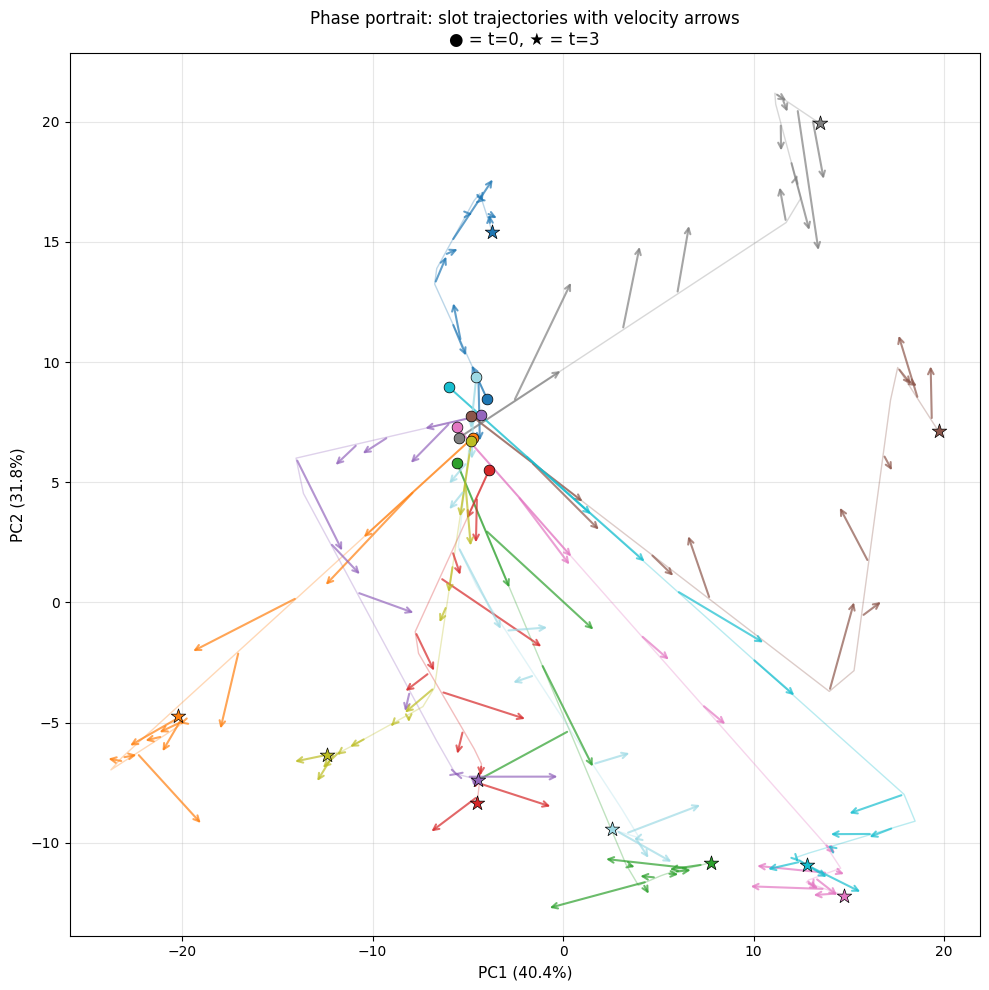

In [21]:
IMG_IDX = 0
traj_img = traj_np[:, IMG_IDX, :, :]  # [T, N_slots, D]

# fit PCA on trajectory points
all_pts = traj_img.reshape(-1, traj_img.shape[-1])
pca_vf = PCA(n_components=2)
pca_vf.fit(all_pts)

# compute velocity at trajectory points and project
n_arrow_pts = 12
arrow_indices = np.linspace(0, T_pts - 2, n_arrow_pts, dtype=int)

fig, ax = plt.subplots(figsize=(10, 10))

for s in range(N_slots):
    traj_s_2d = pca_vf.transform(traj_img[:, s, :])
    ax.plot(traj_s_2d[:, 0], traj_s_2d[:, 1], color=slot_colors[s], alpha=0.3, linewidth=1)
    ax.scatter(traj_s_2d[0, 0], traj_s_2d[0, 1], color=slot_colors[s], marker="o", s=60,
              edgecolors="black", linewidths=0.5, zorder=5)
    ax.scatter(traj_s_2d[-1, 0], traj_s_2d[-1, 1], color=slot_colors[s], marker="*", s=120,
              edgecolors="black", linewidths=0.5, zorder=5)

    for ti in arrow_indices:
        t_val = time_values[ti]
        slots_at_t = jnp.array(traj_np[ti, IMG_IDX:IMG_IDX+1])  # [1, N_slots, D]
        vel = np.array(ode_func(t_val, slots_at_t, (k_single, v_single)))  # [1, N_slots, D]
        vel_s = vel[0, s]  # [D]

        pos_2d = traj_s_2d[ti]
        vel_2d = pca_vf.transform(vel_s.reshape(1, -1))[0] - pca_vf.transform(np.zeros((1, vel_s.shape[0])))[0]

        scale = 0.3
        ax.annotate("", xy=pos_2d + scale * vel_2d, xytext=pos_2d,
                    arrowprops=dict(arrowstyle="->", color=slot_colors[s], lw=1.5, alpha=0.7))

ax.set_xlabel(f"PC1 ({pca_vf.explained_variance_ratio_[0]:.1%})", fontsize=11)
ax.set_ylabel(f"PC2 ({pca_vf.explained_variance_ratio_[1]:.1%})", fontsize=11)
ax.set_title(f"Phase portrait: slot trajectories with velocity arrows\n● = t=0, ★ = t={T_show:.0f}", fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Test-time generalization to different T

Locatello et al. (2020) show that vanilla Slot Attention (trained with T=3) **improves** with more
iterations at test time (Figure 2), because the shared-weight GRU iterates toward a fixed point.

Here we test whether SlotODE (trained with T=3, Euler dt=1.0) generalizes similarly.
We run the ODE to different endpoints T_test and measure reconstruction MSE + visualize masks.
Since the hypernetwork generates *different* weights for t>3, this tests whether
the learned dynamics extrapolate or collapse outside their training range.

In [ ]:
T_TEST_VALUES = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
IMG_IDX = 0
single_img = images_jax[IMG_IDX:IMG_IDX+1]

sa = model.slot_attention_ode

enc_feat_s = model.enc(single_img)
feat_norm_s = jax.vmap(jax.vmap(sa.norm_input))(enc_feat_s)
feat_s = jax.vmap(jax.vmap(sa.fc_input))(feat_norm_s)
k_s = jax.vmap(jax.vmap(sa.to_k))(feat_s)
v_s = jax.vmap(jax.vmap(sa.to_v))(feat_s)

ref_key = jax.random.key(42)
slots_0 = sa.initialize_slots(1, ref_key)

results_by_T = {}
for T_test in T_TEST_VALUES:
    term = diffrax.ODETerm(sa.slot_ode_func)
    solver = diffrax.Euler()
    sol = diffrax.diffeqsolve(
        term, solver, t0=0.0, t1=T_test, dt0=sa.dt0,
        y0=slots_0, args=(k_s, v_s),
        saveat=diffrax.SaveAt(t1=True),
        stepsize_controller=diffrax.ConstantStepSize(),
        max_steps=512,
    )
    slots_T = sol.ys[0]  # [1, N_slots, D]
    recon_T, masks_T = model.dec(slots_T)

    mse = float(jnp.mean((recon_T - single_img) ** 2))
    results_by_T[T_test] = {
        "slots": np.array(slots_T),
        "recon": np.array(recon_T),
        "masks": np.array(masks_T),
        "mse": mse,
    }
    print(f"T={T_test:.1f}: MSE={mse:.6f}")

print(f"\nTrained with T={T_show:.0f}")

T=1.0: MSE=0.025583
T=2.0: MSE=0.025182
T=3.0: MSE=0.000798
T=4.0: MSE=0.017167
T=5.0: MSE=0.024173
T=6.0: MSE=0.018079


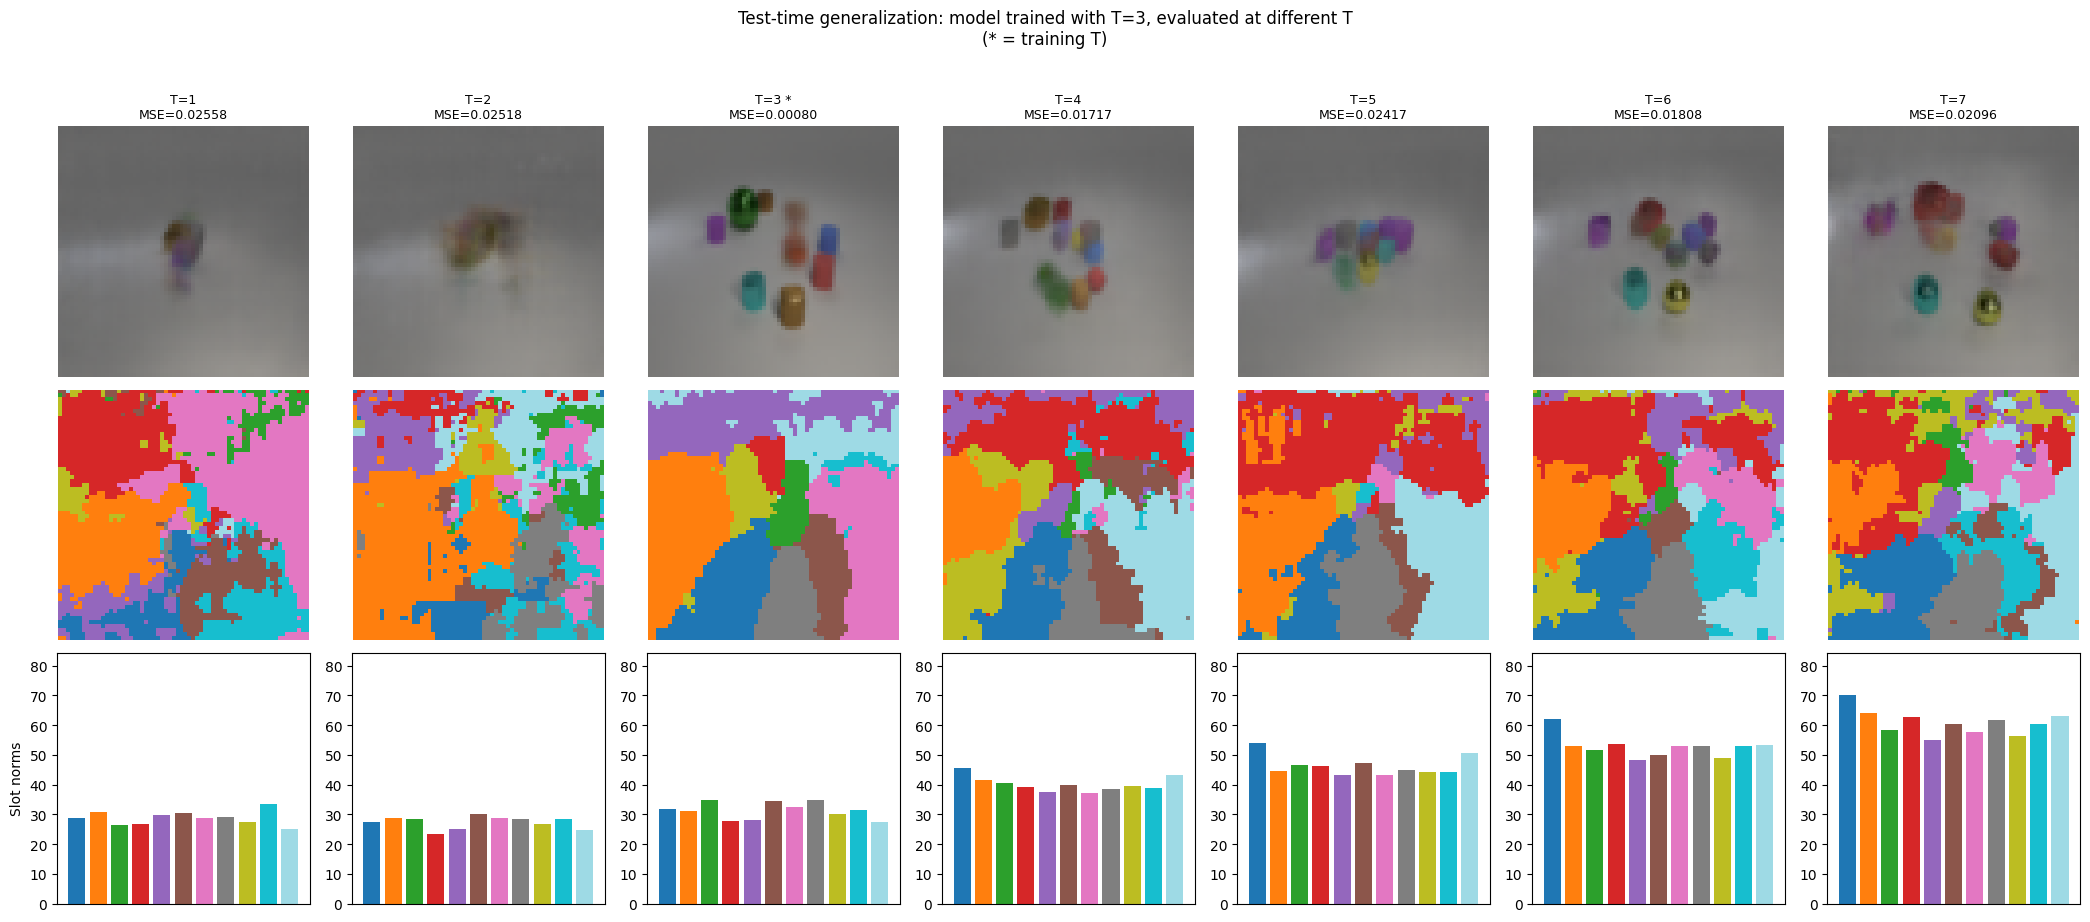

In [23]:
n_T = len(T_TEST_VALUES)
fig, axes = plt.subplots(3, n_T, figsize=(3 * n_T, 9))

for col, T_test in enumerate(T_TEST_VALUES):
    r = results_by_T[T_test]

    axes[0, col].imshow(to_img(r["recon"][0]))
    trained_marker = " *" if T_test == T_show else ""
    axes[0, col].set_title(f"T={T_test:.0f}{trained_marker}\nMSE={r['mse']:.5f}", fontsize=9)
    axes[0, col].axis("off")

    seg = r["masks"][0].argmax(axis=0)
    seg_rgb = np.zeros((*seg.shape, 3))
    for s in range(N_slots):
        seg_rgb[seg == s] = slot_colors[s]
    axes[1, col].imshow(seg_rgb)
    axes[1, col].axis("off")

    slot_norms = np.linalg.norm(r["slots"][0], axis=-1)  # [N_slots]
    axes[2, col].bar(range(N_slots), slot_norms, color=[slot_colors[s] for s in range(N_slots)])
    axes[2, col].set_ylim(0, max(slot_norms.max() * 1.2 for r in results_by_T.values()
                                  for slot_norms in [np.linalg.norm(r["slots"][0], axis=-1)]))
    if col == 0:
        axes[2, col].set_ylabel("‖slot‖", fontsize=10)
    axes[2, col].set_xticks([])

axes[0, 0].set_ylabel("Reconstruction", fontsize=10)
axes[1, 0].set_ylabel("Segmentation", fontsize=10)
axes[2, 0].set_ylabel("Slot norms", fontsize=10)

fig.suptitle(f"Test-time generalization: model trained with T={T_show:.0f}, evaluated at different T\n"
             f"(* = training T)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

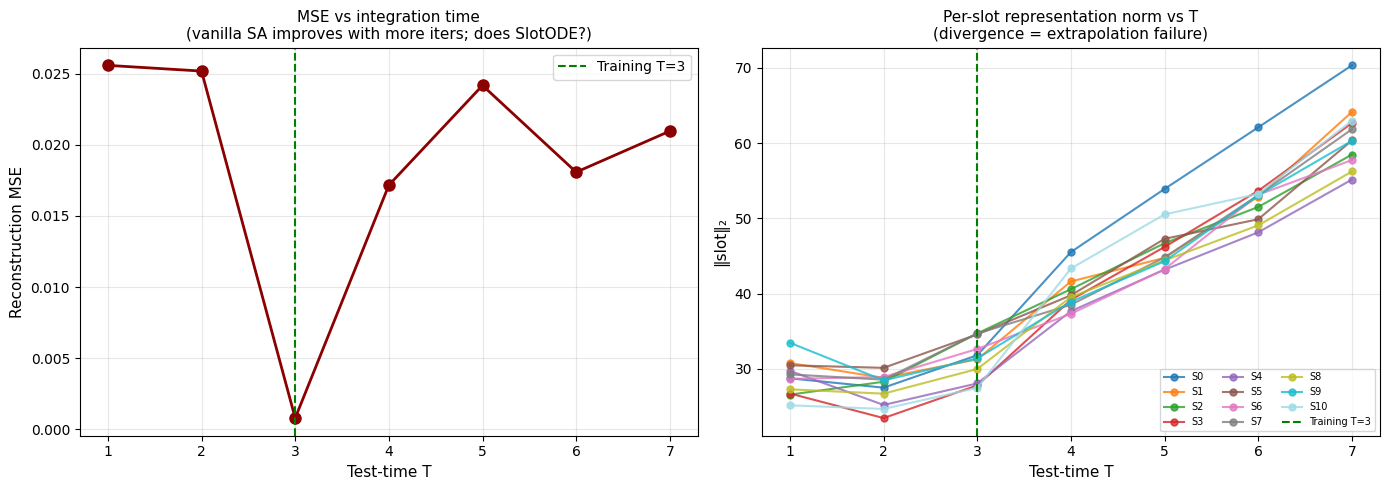

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mses = [results_by_T[T]["mse"] for T in T_TEST_VALUES]

ax = axes[0]
ax.plot(T_TEST_VALUES, mses, "o-", linewidth=2, markersize=8, color="darkred")
ax.axvline(T_show, color="green", linewidth=1.5, linestyle="--", label=f"Training T={T_show:.0f}")
ax.set_xlabel("Test-time T", fontsize=11)
ax.set_ylabel("Reconstruction MSE", fontsize=11)
ax.set_title("MSE vs integration time\n(vanilla SA improves with more iters; does SlotODE?)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# slot norm divergence
ax = axes[1]
for s in range(N_slots):
    norms = [np.linalg.norm(results_by_T[T]["slots"][0, s]) for T in T_TEST_VALUES]
    label = f"S{s}" if slot_activity[s] > 0.15 else None
    alpha = 0.8 if slot_activity[s] > 0.15 else 0.2
    ax.plot(T_TEST_VALUES, norms, "o-", color=slot_colors[s], alpha=alpha, linewidth=1.5,
            markersize=5, label=label)
ax.axvline(T_show, color="green", linewidth=1.5, linestyle="--", label=f"Training T={T_show:.0f}")
ax.set_xlabel("Test-time T", fontsize=11)
ax.set_ylabel("‖slot‖₂", fontsize=11)
ax.set_title("Per-slot representation norm vs T\n(divergence = extrapolation failure)", fontsize=11)
ax.legend(fontsize=7, ncol=3)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Side-by-side: all images at final time

In [ ]:
fig, axes = plt.subplots(4, B, figsize=(4 * B, 14))
if B == 1:
    axes = axes[:, None]

for j in range(B):
    axes[0, j].imshow(to_img(imgs_np[j]))
    axes[0, j].set_title(f"Input {j}", fontsize=10)
    axes[0, j].axis("off")

    axes[1, j].imshow(to_img(recon_np[j]))
    axes[1, j].set_title("Reconstruction", fontsize=10)
    axes[1, j].axis("off")

    seg = masks_np[j].argmax(axis=0)
    seg_rgb = np.zeros((*seg.shape, 3))
    for s in range(N_slots):
        seg_rgb[seg == s] = slot_colors[s]
    axes[2, j].imshow(seg_rgb)
    axes[2, j].set_title("Segmentation", fontsize=10)
    axes[2, j].axis("off")

    masked_recon = np.zeros_like(imgs_np[j].transpose(1, 2, 0))
    for s in range(N_slots):
        color = np.array(slot_colors[s])
        slot_recon = to_img(recon_np[j]) * masks_np[j, s][..., None]
        tint = slot_recon * 0.5 + 0.5 * masks_np[j, s][..., None] * color[None, None, :]
        masked_recon += tint
    axes[3, j].imshow(np.clip(masked_recon, 0, 1))
    axes[3, j].set_title("Color-coded recon", fontsize=10)
    axes[3, j].axis("off")

plt.tight_layout()
plt.show()